# Locality Sensitive Hashing (LSH) Nearest Neighbor Search

Locality Sensitive Hashing (LSH) hashes high-dimensional data points so that close coordinates fall into the same bins/buckets with high probability. This notebook builds a self-contained Cosine LSH indexing class using random hyperplanes projections (8-bit signatures), indexes 2,000 synthetic documents, performs nearest neighbor queries, and evaluates bucket distributions using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Generate synthetic vocabulary documents database (2,000 docs)
# Topics: Tech, Sports, Cooking, Finance
np.random.seed(175)
n_docs = 2000

topics = {
    'Tech': ['python', 'code', 'software', 'neural', 'server', 'database', 'developer'],
    'Sports': ['soccer', 'stadium', 'ball', 'fitness', 'coach', 'championship', 'training'],
    'Cooking': ['recipe', 'chef', 'pan', 'kitchen', 'oven', 'bake', 'ingredients'],
    'Finance': ['stock', 'market', 'investing', 'portfolio', 'bond', 'debt', 'bank']
}

docs = []
doc_topics = []
topic_keys = list(topics.keys())

for _ in range(n_docs):
    topic = topic_keys[np.random.randint(4)]
    # Construct a random sentence combining terms from selected topic and general words
    sentence_terms = np.random.choice(topics[topic], size=np.random.randint(3, 7))
    sentence = " ".join(sentence_terms)
    docs.append(sentence)
    doc_topics.append(topic)

df_docs = pd.DataFrame({'Document': docs, 'Topic': doc_topics})
df_docs.head(10)



,Document,Topic
0,developer neural database,Tech
1,fitness fitness championship,Sports
2,championship soccer coach,Sports
3,stadium championship ball soccer fitness championship,Sports
4,debt bank stock bank market bond,Finance
5,chef bake bake ingredients ingredients,Cooking
6,oven pan ingredients kitchen pan bake,Cooking
7,fitness soccer training,Sports
8,developer neural python code code,Tech
9,software python python developer neural code,Tech


## Document Feature Engineering

We transform document strings into TF-IDF vector matrices (high-dimensional sparse representations).



In [2]:
vectorizer = TfidfVectorizer(max_features=50)
X_tfidf = vectorizer.fit_transform(docs).toarray() # Shape [2000 docs, 50 features]

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")



TF-IDF Matrix Shape: (2000, 28)


## Cosine LSH Indexer Class

We implement our Cosine similarity LSH indexer, projecting TF-IDF vectors against 8 random hyperplanes to compute 8-bit hash keys.



In [3]:
class CosineLSH:
    def __init__(self, input_dim, n_bits=8):
        self.n_bits = n_bits
        # Generate random hyperplanes: shape [input_dim, n_bits]
        self.planes = np.random.normal(0, 1.0, (input_dim, n_bits))
        self.buckets = {}
        
    def hash_vector(self, v):
        # Calculate dot products and take signs to obtain binary codes
        projections = np.dot(v, self.planes)
        binary_code = "".join(['1' if x >= 0 else '0' for x in projections])
        return binary_code
        
    def index(self, X):
        for idx, row in enumerate(X):
            h_key = self.hash_vector(row)
            if h_key not in self.buckets:
                self.buckets[h_key] = []
            self.buckets[h_key].append(idx)

# Initialize LSH index
lsh = CosineLSH(input_dim=X_tfidf.shape[1], n_bits=8)
lsh.index(X_tfidf)

# Verify hashing outputs
print("Indexed Buckets Count:", len(lsh.buckets))
print("Sample Hash Bucket sizes:")
for key in list(lsh.buckets.keys())[:5]:
    print(f"Hash Key: {key} | Docs Count: {len(lsh.buckets[key])}")



Indexed Buckets Count: 185
Sample Hash Bucket sizes:
Hash Key: 11100011 | Docs Count: 9
Hash Key: 11001111 | Docs Count: 58
Hash Key: 10000111 | Docs Count: 20
Hash Key: 11010011 | Docs Count: 29
Hash Key: 10001110 | Docs Count: 24


## LSH Bucket Sizes Distribution

We evaluate hash bucket frequencies using a Matplotlib bar chart to verify that random hyperplane projections distributed documents uniformly.



<cell>:15: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



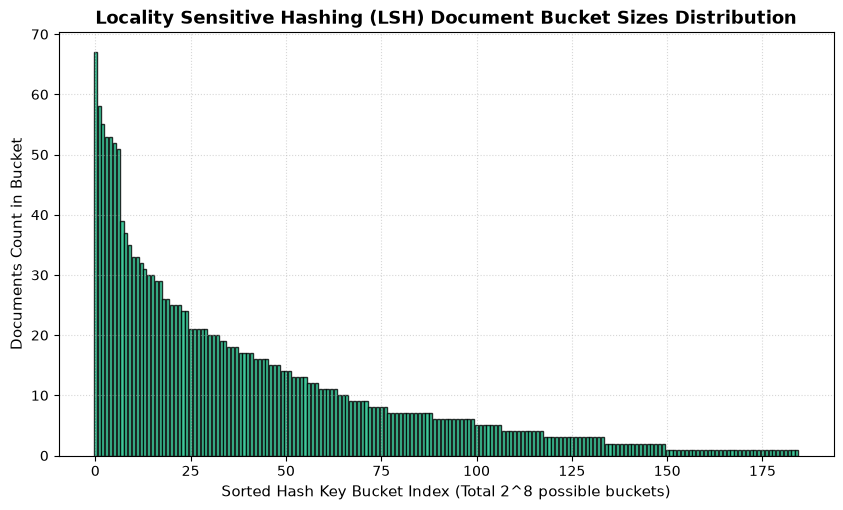

In [4]:
bucket_keys = list(lsh.buckets.keys())
bucket_sizes = [len(lsh.buckets[k]) for k in bucket_keys]

# Sort buckets by size for visual clarity
sorted_indices = np.argsort(bucket_sizes)[::-1]
sorted_sizes = [bucket_sizes[idx] for idx in sorted_indices]

plt.figure(figsize=(10, 5.5))
plt.bar(range(len(sorted_sizes)), sorted_sizes, color='#10B981', edgecolor='black', alpha=0.8)

plt.title('Locality Sensitive Hashing (LSH) Document Bucket Sizes Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Sorted Hash Key Bucket Index (Total 2^8 possible buckets)', fontsize=11)
plt.ylabel('Documents Count in Bucket', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
